# **FINAL PROJECT FUNDAMENTALS OF DEEP LEARNING 2025**

![flickr-logo[1].png](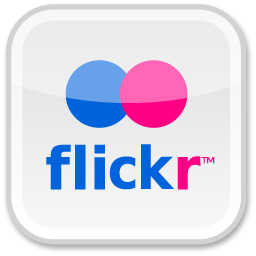)

In [ ]:
# !pip install tensorflow

# Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import tensorflow as tf

# Keras imports
from tensorflow.keras import backend as K, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout, BatchNormalization, Conv2D, MaxPooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0


# Load Data and Prepare for Modelling

In [4]:
# DATA LOADING
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -qq Flickr8k_Dataset.zip
!unzip -qq Flickr8k_text.zip
!rm Flickr8k_Dataset.zip Flickr8k_text.zip

In [6]:
# Train Dataset RGB
train_df = pd.read_csv('train_image_class.csv')
train_df['Image Path'] = train_df['Image Path'].apply(lambda x: os.path.join(IMAGES_PATH, x))

train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='Image Path',  #DataFrame column name
    y_col='Label',       #DataFrame column name
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Train Dataset Grayscale

train_generator_gray = train_datagen.flow_from_dataframe(
    train_df,
    x_col='Image Path',
    y_col='Label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale' # Grayscale Images
)

Found 6114 validated image filenames belonging to 5 classes.
Found 6114 validated image filenames belonging to 5 classes.


In [7]:
train_df.head(5)

,Image Path,Label
0,Flicker8k_Dataset/3459362347_c412ef9901.jpg,people
1,Flicker8k_Dataset/2080033499_6be742f483.jpg,animals
2,Flicker8k_Dataset/506478284_7cf8bdbe36.jpg,others
3,Flicker8k_Dataset/861795382_5145ad433d.jpg,people
4,Flicker8k_Dataset/1342766791_1e72f92455.jpg,people


In [8]:
# Validation Dataset

val_df = pd.read_csv('valid_image_class.csv')
val_df['Image Path'] = val_df['Image Path'].apply(lambda x: os.path.join(IMAGES_PATH, x))

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='Image Path',  #DataFrame column name
    y_col='Label',       #DataFrame column name
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


# Val Dataset Grayscale

val_generator_gray = val_datagen.flow_from_dataframe(
    val_df,
    x_col='Image Path',
    y_col='Label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale' # Grayscale Images
)

Found 1529 validated image filenames belonging to 5 classes.
Found 1529 validated image filenames belonging to 5 classes.


In [9]:
val_df.head(5)

,Image Path,Label
0,Flicker8k_Dataset/1802092493_7b44fdb6b9.jpg,people
1,Flicker8k_Dataset/374103776_0de490c1b0.jpg,people
2,Flicker8k_Dataset/1048710776_bb5b0a5c7c.jpg,people
3,Flicker8k_Dataset/2982881046_45765ced2c.jpg,people
4,Flicker8k_Dataset/917574521_74fab68514.jpg,people


In [10]:
num_classes = 5 # Number of distinct Labels

# Modelling

#MLP

###MLP - RGB

In [ ]:
num_classes = 5 # Number of distinct Labels

model = Sequential()
model.add(Flatten(input_shape=(224, 224, 3))) # RGB image data
model.add(Dense(16, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

batch_size  = 32
epochs      = 20

model.fit(
  train_generator,
  batch_size=batch_size,
  epochs=epochs,
  verbose=1,
  validation_data=val_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 150528)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │       2,408,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,411,445 (9.20 MB)

 Trainable params: 2,411,445 (9.20 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 33s 159ms/step - accuracy: 0.4552 - loss: 5.9459 - val_accuracy: 0.5337 - val_loss: 1.2385
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - accuracy: 0.5344 - loss: 1.1961 - val_accuracy: 0.5337 - val_loss: 1.1789
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.5514 - loss: 1.1519 - val_accuracy: 0.5337 - val_loss: 1.1767
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 28s 145ms/step - accuracy: 0.5502 - loss: 1.1640 - val_accuracy: 0.5337 - val_loss: 1.1754
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - accuracy: 0.5486 - loss: 1.1521 - val_accuracy: 0.5337 - val_loss: 1.1770
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.5496 - loss: 1.1562 - val_accuracy: 0.5337 - val_loss: 1.1768
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.5522 - loss: 1.1617 - val_accuracy: 0.5337 - val_loss: 1.1749
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.5481 - loss: 1

### MLP - Model - V1

In [ ]:
# Initialize mlp_model_v1 (greyscale) with different configurations.

mlp_model_v1 = Sequential()
mlp_model_v1.add(Flatten(input_shape=(224, 224, 1))) # Gray image data
mlp_model_v1.add(Dense(16, activation='relu'))
mlp_model_v1.add(Dense(32, activation='relu'))
mlp_model_v1.add(Dense(64, activation='relu'))
mlp_model_v1.add(Dense(num_classes, activation='softmax'))

mlp_model_v1.summary()

mlp_model_v1.compile(loss='categorical_crossentropy', metrics=['accuracy'])

batch_size  = 32
epochs      = 20

mlp_model_v1.fit(
  train_generator_gray,
  batch_size=batch_size,
  epochs=epochs,
  verbose=1,
  validation_data=val_generator_gray
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 16)                  │         802,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 805,813 (3.07 MB)

 Trainable params: 805,813 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 143ms/step - accuracy: 0.4403 - loss: 2.7742 - val_accuracy: 0.5023 - val_loss: 1.2224
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.5426 - loss: 1.2262 - val_accuracy: 0.5337 - val_loss: 1.2163
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5408 - loss: 1.2191 - val_accuracy: 0.5337 - val_loss: 1.1801
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.5452 - loss: 1.1592 - val_accuracy: 0.5337 - val_loss: 1.1772
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.5489 - loss: 1.1600 - val_accuracy: 0.5337 - val_loss: 1.1775
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.5461 - loss: 1.1572 - val_accuracy: 0.5337 - val_loss: 1.1769
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5526 - loss: 1.1614 - val_accuracy: 0.5337 - val_loss: 1.1756
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.5514 - loss: 1

### MLP - Model - V2

In [ ]:
# Initialize mlp_model_v2 (greyscale) with different configurations.

mlp_model_v2 = Sequential()
mlp_model_v2.add(Flatten(input_shape=(224, 224, 1)))  # Gray image data
mlp_model_v2.add(Dense(32, activation='relu'))
mlp_model_v2.add(BatchNormalization())
mlp_model_v2.add(Dense(64, activation='relu'))
mlp_model_v2.add(Dropout(0.3))
mlp_model_v2.add(Dense(128, activation='relu'))
mlp_model_v2.add(Dropout(0.4))
mlp_model_v2.add(Dense(num_classes, activation='softmax'))

mlp_model_v2.summary()

mlp_model_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

batch_size  = 32
epochs      = 20

mlp_model_v2.fit(
  train_generator_gray,
  batch_size=batch_size,
  epochs=epochs,
  verbose=1,
  validation_data=val_generator_gray
)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 32)                  │       1,605,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,616,869 (6.17 MB)

 Trainable params: 1,616,805 (6.17 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.4805 - loss: 1.3261 - val_accuracy: 0.5343 - val_loss: 1.1889
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.5240 - loss: 1.1841 - val_accuracy: 0.5337 - val_loss: 1.1729
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.5401 - loss: 1.1527 - val_accuracy: 0.5350 - val_loss: 1.2099
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.5392 - loss: 1.1455 - val_accuracy: 0.5337 - val_loss: 1.2285
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5473 - loss: 1.1228 - val_accuracy: 0.5337 - val_loss: 1.1483
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.5588 - loss: 1.0840 - val_accuracy: 0.5258 - val_loss: 1.2245
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - accuracy: 0.5677 - loss: 1.0685 - val_accuracy: 0.5298 - val_loss: 1.9952
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.5790 - loss: 1

### MLP - Model - V3

In [ ]:
# Initialize mlp_model_v3 (greyscale) with different configurations.

mlp_model_v3 = Sequential()
mlp_model_v3.add(Flatten(input_shape=(224, 224, 1)))  # Gray image data

# Add layers with L2 regularization and adjusted neuron counts
mlp_model_v3.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
mlp_model_v3.add(BatchNormalization())
mlp_model_v3.add(Dropout(0.4))  # Increased dropout rate

mlp_model_v3.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
mlp_model_v3.add(BatchNormalization())
mlp_model_v3.add(Dropout(0.5))  # Increased dropout rate

mlp_model_v3.add(Dense(num_classes, activation='softmax'))

mlp_model_v3.summary()

mlp_model_v3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

batch_size  = 32  # You might experiment with different batch sizes
epochs      = 30  # Increased epochs for more training time

mlp_model_v3.fit(
  train_generator_gray,
  batch_size=batch_size,
  epochs=epochs,
  verbose=1,
  validation_data=val_generator_gray
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 64)                  │       3,211,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,221,061 (12.29 MB)

 Trainable params: 3,220,677 (12.29 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 33s 153ms/step - accuracy: 0.2713 - loss: 2.4428 - val_accuracy: 0.5337 - val_loss: 1.5656
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.4411 - loss: 1.7899 - val_accuracy: 0.5370 - val_loss: 1.4272
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.4822 - loss: 1.5593 - val_accuracy: 0.5330 - val_loss: 1.3656
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5000 - loss: 1.4704 - val_accuracy: 0.5324 - val_loss: 1.3458
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5144 - loss: 1.3903 - val_accuracy: 0.5304 - val_loss: 1.3045
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.5298 - loss: 1.3278 - val_accuracy: 0.5356 - val_loss: 1.2961
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.5403 - loss: 1.3175 - val_accuracy: 0.5337 - val_loss: 1.3263
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5329 - loss: 1

# CNN

###CNN - RGB

In [ ]:
# Initiate CNN Model with predefined Architecture on RGB Data

model = Sequential()
# first conv layer
model.add(Conv2D(8, (2, 2), input_shape=(224, 224, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(6, 6), strides=2))
# second conv layer
model.add(Conv2D(64, (3, 3), activation='gelu'))
model.add(MaxPooling2D(pool_size=(6, 6), strides=1, padding='same'))
# Flatten and Fully Connected Layer
model.add(Flatten())
model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 32
epochs = 5

model.fit(train_generator,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(val_generator))



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 223, 223, 8)         │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 109, 109, 8)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 107, 107, 64)        │           4,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 107, 107, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 732736)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │      93,790,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,795,757 (357.80 MB)

 Trainable params: 93,795,757 (357.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 174ms/step - accuracy: 0.4508 - loss: 8.3144 - val_accuracy: 0.5520 - val_loss: 1.1566
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.5970 - loss: 1.0428 - val_accuracy: 0.4820 - val_loss: 1.2162
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step - accuracy: 0.6255 - loss: 0.9633 - val_accuracy: 0.5448 - val_loss: 1.1425
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - accuracy: 0.6807 - loss: 0.8349 - val_accuracy: 0.5167 - val_loss: 1.2485
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 166ms/step - accuracy: 0.7273 - loss: 0.7184 - val_accuracy: 0.5860 - val_loss: 1.2645


###CNN - Model - V1

In [ ]:

cnn_model_v1 = Sequential()
# First conv layer (increase filters)
cnn_model_v1.add(Conv2D(16, (3,3), input_shape=(224, 224, 3), activation='relu', padding='same'))
cnn_model_v1.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Second conv layer (increase filters)
cnn_model_v1.add(Conv2D(64, (3,3), activation='gelu', padding='same'))
cnn_model_v1.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Third conv layer (new)
cnn_model_v1.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model_v1.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten and Fully Connected Layer
cnn_model_v1.add(Flatten())
cnn_model_v1.add(Dense(256, activation='relu'))
cnn_model_v1.add(Dense(num_classes, activation='softmax'))

cnn_model_v1.summary()

cnn_model_v1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 32
epochs = 5

cnn_model_v1.fit(train_generator,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(val_generator))


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 112, 112, 64)        │           9,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,775,237 (98.32 MB)

 Trainable params: 25,775,237 (98.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 42s 200ms/step - accuracy: 0.5212 - loss: 1.4689 - val_accuracy: 0.5932 - val_loss: 1.0990
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 156ms/step - accuracy: 0.6051 - loss: 1.0572 - val_accuracy: 0.5997 - val_loss: 1.0960
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - accuracy: 0.6245 - loss: 0.9539 - val_accuracy: 0.6076 - val_loss: 1.0982
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 35s 183ms/step - accuracy: 0.7233 - loss: 0.7205 - val_accuracy: 0.5625 - val_loss: 1.3912
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - accuracy: 0.8403 - loss: 0.4326 - val_accuracy: 0.5376 - val_loss: 1.8217


###CNN - Model - V2

In [ ]:

cnn_model_v2 = Sequential()
# First conv layer
cnn_model_v2.add(Conv2D(16, (3,3), input_shape=(224, 224, 3), activation='relu', padding='same'))
cnn_model_v2.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Second conv layer
cnn_model_v2.add(Conv2D(64, (3,3), activation='gelu', padding='same'))
cnn_model_v2.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Third conv layer
cnn_model_v2.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model_v2.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten and Fully Connected Layer
cnn_model_v2.add(Flatten())
cnn_model_v2.add(Dense(256, activation='relu'))
cnn_model_v2.add(Dropout(0.5))  # Dropout to prevent overfitting
cnn_model_v2.add(Dense(num_classes, activation='softmax'))

cnn_model_v2.summary()

cnn_model_v2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 32
epochs = 5

cnn_model_v2.fit(train_generator,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(val_generator))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 112, 112, 64)        │           9,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_14 (Flatten)                 │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,775,237 (98.32 MB)

 Trainable params: 25,775,237 (98.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.5311 - loss: 1.3962 - val_accuracy: 0.5461 - val_loss: 1.1065
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - accuracy: 0.5993 - loss: 1.0772 - val_accuracy: 0.5971 - val_loss: 1.0483
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - accuracy: 0.5926 - loss: 1.0555 - val_accuracy: 0.6095 - val_loss: 1.0568
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.6361 - loss: 0.9634 - val_accuracy: 0.6063 - val_loss: 1.0492
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 161ms/step - accuracy: 0.6581 - loss: 0.8786 - val_accuracy: 0.6024 - val_loss: 1.1089


###CNN - Model - V3

In [ ]:
cnn_model_v3 = Sequential()
# First conv layer
cnn_model_v3.add(Conv2D(32, (3,3), input_shape=(224, 224, 3), activation='relu', padding='same'))
cnn_model_v3.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Second conv layer
cnn_model_v3.add(Conv2D(64, (3,3), activation='gelu', padding='same'))
cnn_model_v3.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Third conv layer
cnn_model_v3.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model_v3.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten and Fully Connected Layer
cnn_model_v3.add(Flatten())
cnn_model_v3.add(Dense(256, activation='relu'))
cnn_model_v3.add(Dropout(0.5))  # Dropout to prevent overfitting
cnn_model_v3.add(Dense(num_classes, activation='softmax'))

cnn_model_v3.summary()

cnn_model_v3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 32
epochs = 5

cnn_model_v3.fit(train_generator,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(val_generator))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,784,901 (98.36 MB)

 Trainable params: 25,784,901 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.5339 - loss: 1.3574 - val_accuracy: 0.5801 - val_loss: 1.0931
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - accuracy: 0.6011 - loss: 1.0804 - val_accuracy: 0.5873 - val_loss: 1.0564
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - accuracy: 0.6125 - loss: 1.0317 - val_accuracy: 0.5958 - val_loss: 1.1352
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 166ms/step - accuracy: 0.6451 - loss: 0.9288 - val_accuracy: 0.6233 - val_loss: 1.0752
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 157ms/step - accuracy: 0.6813 - loss: 0.8170 - val_accuracy: 0.6161 - val_loss: 1.1655


###CNN - Model - V4

In [ ]:

cnn_model_v4 = Sequential()
# First conv layer
cnn_model_v4.add(Conv2D(32, (3,3), input_shape=(224, 224, 3), activation='relu', padding='same'))
cnn_model_v4.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Second conv layer
cnn_model_v4.add(Conv2D(64, (3,3), activation='gelu', padding='same'))
cnn_model_v4.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Third conv layer
cnn_model_v4.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model_v4.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten and Fully Connected Layer
cnn_model_v4.add(Flatten())
cnn_model_v4.add(Dense(256, activation='relu'))
cnn_model_v4.add(Dropout(0.5))  # Dropout to prevent overfitting
cnn_model_v4.add(Dense(num_classes, activation='softmax'))

cnn_model_v4.summary()


batch_size = 32
epochs = 10

# Define optimizer with momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9)

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)

cnn_model_v4.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

cnn_model_v4.fit(train_generator, epochs=epochs, validation_data=val_generator, callbacks=[lr_scheduler])


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_17 (Flatten)                 │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,784,901 (98.36 MB)

 Trainable params: 25,784,901 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - accuracy: 0.5265 - loss: 1.2393 - val_accuracy: 0.5441 - val_loss: 1.1369 - learning_rate: 0.0100
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - accuracy: 0.5510 - loss: 1.1383 - val_accuracy: 0.5585 - val_loss: 1.1086 - learning_rate: 0.0100
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - accuracy: 0.5869 - loss: 1.0970 - val_accuracy: 0.5952 - val_loss: 1.0619 - learning_rate: 0.0100
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.5882 - loss: 1.0767 - val_accuracy: 0.6017 - val_loss: 1.0596 - learning_rate: 0.0100
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 157ms/step - accuracy: 0.6061 - loss: 1.0344 - val_accuracy: 0.6194 - val_loss: 1.0268 - learning_rate: 0.0100
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.6131 - loss: 1.0161 - val_accuracy: 0.5965 - val_loss: 1.0704 - learning_rate: 0.0100
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - accuracy: 0.6

### CNN - Model - V4 w/ Data Augementation (Best!)

###Data Augmentation

In [11]:
# Train Data Augmentation - Including random transformations
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values between 0 and 1
    rotation_range=15,          # Randomly rotate images by 15 degrees
    width_shift_range=0.2,      # Randomly shift images horizontally by 20%
    height_shift_range=0.2,     # Randomly shift images vertically by 20%
    shear_range=0.2,            # Randomly apply shearing transformation
    zoom_range=0.2,             # Random zoom
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'        # Fill missing pixels after transformations


)

# Data Generator for Training Set with Augmentation
train_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_df,
    x_col='Image Path',  # Column name with image paths
    y_col='Label',       # Column name with the labels
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'

)



Found 6114 validated image filenames belonging to 5 classes.


###Cnn - Model - V4 - Aug

In [ ]:
# Define CNN Model
cnn_model_v4_aug = Sequential()

# First conv layer
cnn_model_v4_aug.add(Conv2D(32, (3,3), input_shape=(224, 224, 3), activation='relu', padding='same'))
cnn_model_v4_aug.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Second conv layer
cnn_model_v4_aug.add(Conv2D(64, (3,3), activation='gelu', padding='same'))
cnn_model_v4_aug.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Third conv layer
cnn_model_v4_aug.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model_v4_aug.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten and Fully Connected Layer
cnn_model_v4_aug.add(Flatten())
cnn_model_v4_aug.add(Dense(256, activation='relu'))
cnn_model_v4_aug.add(Dropout(0.5))  # Dropout to prevent overfitting
cnn_model_v4_aug.add(Dense(num_classes, activation='softmax'))

# Model Summary
cnn_model_v4_aug.summary()

# Training Parameters
batch_size = 32
epochs = 10

# Optimizer with momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9)

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)

# Compile the model
cnn_model_v4_aug.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Train the model with augmented data
cnn_model_v4_aug.fit(train_generator_aug, epochs=epochs, validation_data=val_generator, callbacks=[lr_scheduler])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,784,901 (98.36 MB)

 Trainable params: 25,784,901 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 101s 491ms/step - accuracy: 0.5244 - loss: 1.2574 - val_accuracy: 0.5337 - val_loss: 1.1706 - learning_rate: 0.0100
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 90s 469ms/step - accuracy: 0.5486 - loss: 1.1892 - val_accuracy: 0.5337 - val_loss: 1.1499 - learning_rate: 0.0100
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 90s 469ms/step - accuracy: 0.5411 - loss: 1.1471 - val_accuracy: 0.5324 - val_loss: 1.1311 - learning_rate: 0.0100
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 92s 477ms/step - accuracy: 0.5657 - loss: 1.1303 - val_accuracy: 0.5383 - val_loss: 1.1230 - learning_rate: 0.0100
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 90s 469ms/step - accuracy: 0.5553 - loss: 1.1229 - val_accuracy: 0.5749 - val_loss: 1.0866 - learning_rate: 0.0100
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 95s 497ms/step - accuracy: 0.5731 - loss: 1.1084 - val_accuracy: 0.5840 - val_loss: 1.0879 - learning_rate: 0.0100
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 89s 465ms/step - accuracy: 0.

#Explainability

In [ ]:
!pip install tensorflow==2.15 # downgrade tensorflow version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully unin

In [ ]:
#Initialise cnn_model_v4_aug

# Define CNN Model
cnn_model_v4_aug = Sequential()

# First conv layer
cnn_model_v4_aug.add(Conv2D(32, (3,3), input_shape=(224, 224, 3), activation='relu', padding='same'))
cnn_model_v4_aug.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Second conv layer
cnn_model_v4_aug.add(Conv2D(64, (3,3), activation='gelu', padding='same'))
cnn_model_v4_aug.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Third conv layer
cnn_model_v4_aug.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model_v4_aug.add(MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten and Fully Connected Layer
cnn_model_v4_aug.add(Flatten())
cnn_model_v4_aug.add(Dense(256, activation='relu'))
cnn_model_v4_aug.add(Dropout(0.5))  # Dropout to prevent overfitting
cnn_model_v4_aug.add(Dense(num_classes, activation='softmax'))

# Model Summary
cnn_model_v4_aug.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 28, 28, 128)       0

###Activation Visualization


Activations for Image 1
1/1 [==============================] - 0s 190ms/step


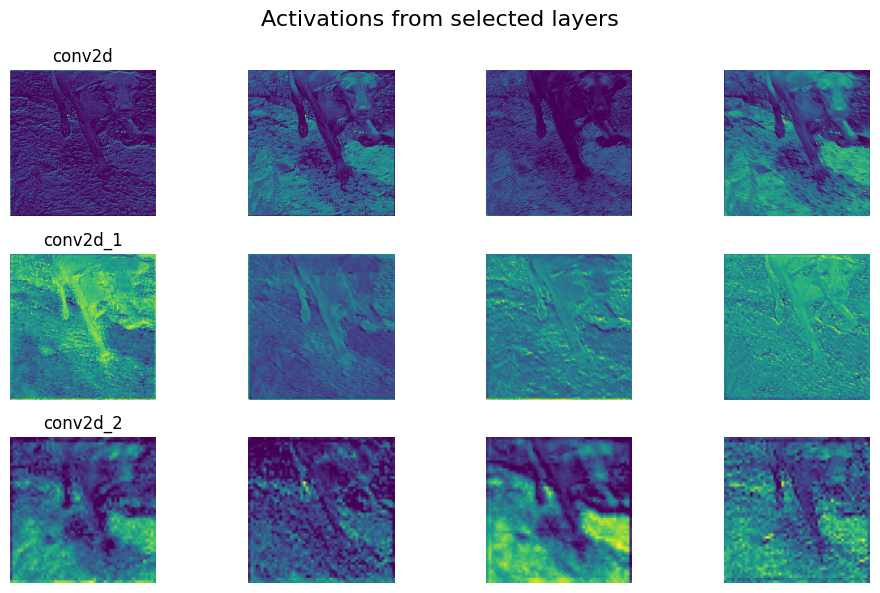


Activations for Image 2
1/1 [==============================] - 0s 100ms/step


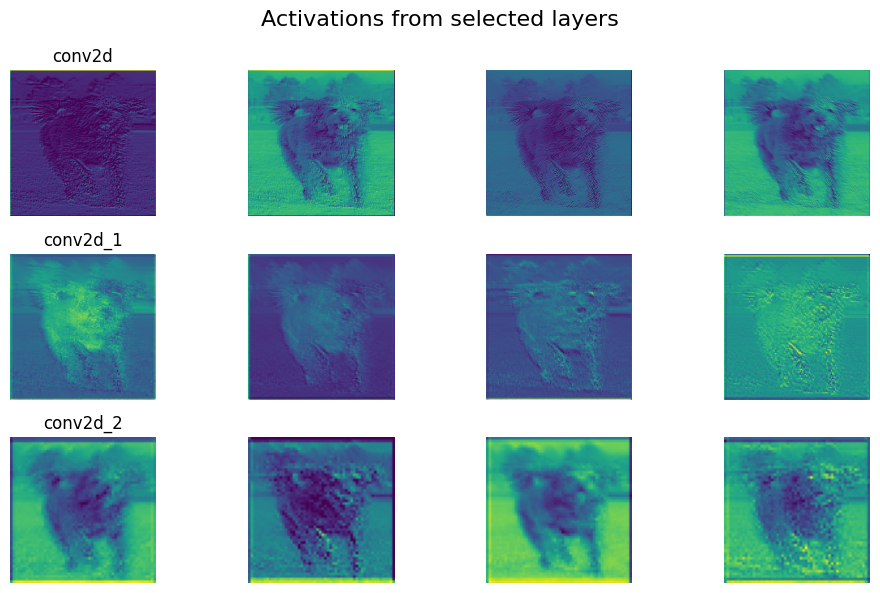


Activations for Image 3
1/1 [==============================] - 0s 91ms/step


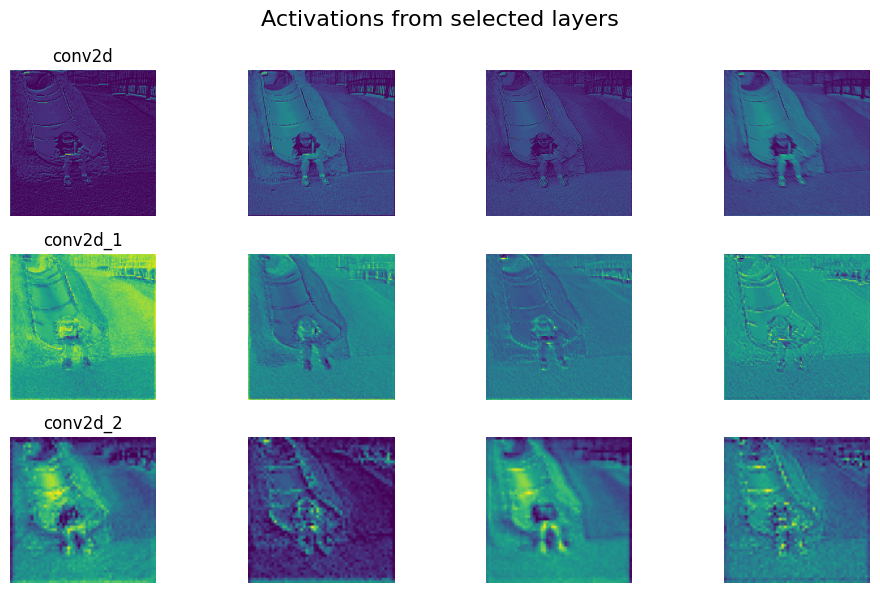

In [ ]:
# Import necessary libraries

# Select a sample image from the validation generator
sample_image = next(val_generator)[0][0:1]  # First image in batch

# Function to visualize activations from selected layers
def visualize_layer_activations(model, sample_image, layer_names):
    activation_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer).output for layer in layer_names]
    )

    # Run a forward pass to get activations
    activations = activation_model.predict(sample_image)

    # Plot activations
    fig, axes = plt.subplots(len(layer_names), 4, figsize=(10, len(layer_names) * 2))
    fig.suptitle("Activations from selected layers", fontsize=16)

    for layer_idx, activation in enumerate(activations):
        for filter_idx in range(min(4, activation.shape[-1])):  # Show up to 4 feature maps
            ax = axes[layer_idx, filter_idx]
            ax.imshow(activation[0, :, :, filter_idx], cmap='viridis')
            ax.axis('off')
            if filter_idx == 0:
                ax.set_title(layer_names[layer_idx])

    plt.tight_layout()
    plt.show()

# Extract convolutional layers from cnn_model_v4_aug
conv_layers = [layer.name for layer in cnn_model_v4_aug.layers if 'conv' in layer.name]

# Visualize activations for the first 3 validation images
for i in range(3):
    sample_image = next(val_generator)[0][i:i+1]  # Get i-th image
    print(f"\nActivations for Image {i+1}")
    visualize_layer_activations(cnn_model_v4_aug, sample_image, conv_layers[:3])  # Show first 3 conv layers



###Grad-CAM (Gradient-weighted Class Activation Mapping)

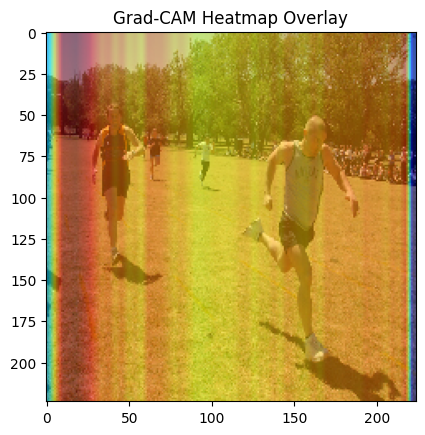

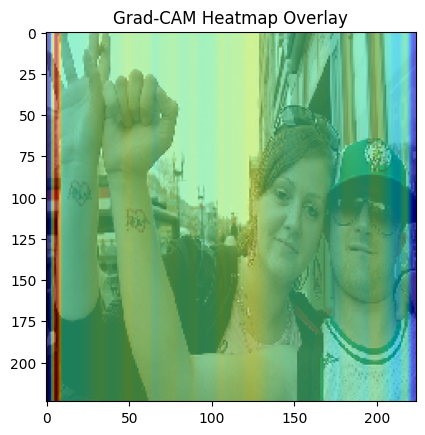

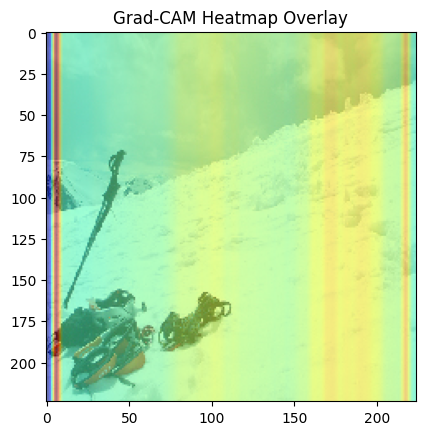

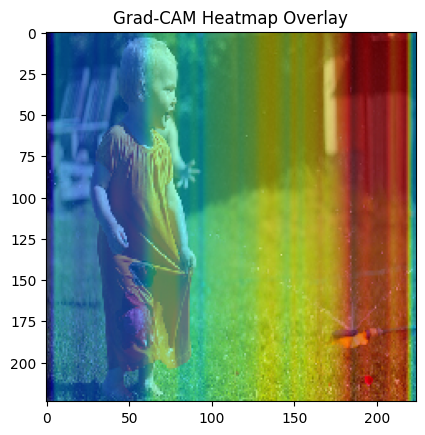

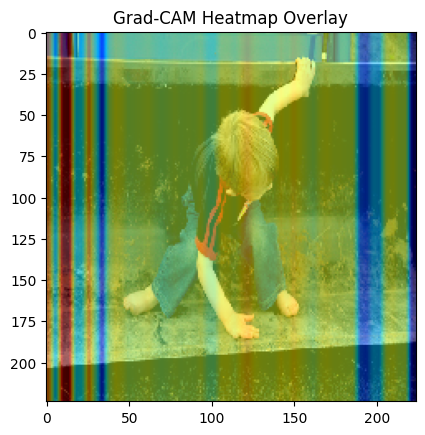

In [ ]:
# Create GRAD-CAM Function

def grad_cam(model, image, layer_name="conv2d_2"):
    """Generates a Grad-CAM heatmap."""
    grad_model = Model(inputs=[model.inputs], outputs=[model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.array([image]))
        loss = predictions[:, np.argmax(predictions[0])]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.image.resize(heatmap, (image.shape[0], image.shape[1]))
    heatmap = tf.squeeze(heatmap)
    return heatmap.numpy()

# Number of images to display
num_images = 5

# Loop through images and display heatmaps
for i in range(num_images):
    # Get the next image from the validation generator
    image = next(val_generator)[0][0]

    # Generate Grad-CAM heatmap
    heatmap = grad_cam(cnn_model_v4_aug, image)

    # Average across channels to get a 2D heatmap
    heatmap = np.mean(heatmap, axis=-1)

    # Display the original image and overlay the heatmap
    plt.figure()  # Create a new figure for each image
    plt.imshow(image)  # Display the original image
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with transparency
    plt.title("Grad-CAM Heatmap Overlay")  # Set the title

    plt.show() # Show the combined image

#Transfer Learning W/ EfficientNetB0

In [12]:

# Load EfficientNetB0 without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Freeze base model layers initially
base_model.trainable = False

# Custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

# Build and compile model
model_tl = Model(inputs=base_model.input, outputs=output)
model_tl.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Summary
model_tl.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
# Train the model with frozen base layers
history = model_tl.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=len(train_generator_aug),
    validation_steps=len(val_generator)
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


192/192 ━━━━━━━━━━━━━━━━━━━━ 799s 4s/step - accuracy: 0.5377 - loss: 1.2345 - val_accuracy: 0.5337 - val_loss: 1.1819
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 780s 4s/step - accuracy: 0.5316 - loss: 1.1916 - val_accuracy: 0.5337 - val_loss: 1.1786
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 770s 4s/step - accuracy: 0.5482 - loss: 1.1787 - val_accuracy: 0.5337 - val_loss: 1.1778
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 782s 4s/step - accuracy: 0.5478 - loss: 1.1916 - val_accuracy: 0.5337 - val_loss: 1.1764
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 777s 4s/step - accuracy: 0.5349 - loss: 1.1992 - val_accuracy: 0.5337 - val_loss: 1.1826
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 775s 4s/step - accuracy: 0.5472 - loss: 1.1734 - val_accuracy: 0.5337 - val_loss: 1.1758
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 773s 4s/step - accuracy: 0.5496 - loss: 1.1794 - val_accuracy: 0.5337 - val_loss: 1.1776
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 775s 4s/step - accuracy: 0.5456 - loss: 1.1653 - val_accuracy: 0.533

In [15]:
# Unfreeze the last few layers for fine-tuning
for layer in base_model.layers[-10:]:  # Unfreezing last 20 layers
    layer.trainable = True

# Compile with a lower learning rate for stability
model_tl.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model again
history_finetune = model_tl.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=5,
    steps_per_epoch=len(train_generator_aug),
    validation_steps=len(val_generator)
)


Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 834s 4s/step - accuracy: 0.5054 - loss: 1.3745 - val_accuracy: 0.5337 - val_loss: 1.2604
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 816s 4s/step - accuracy: 0.5246 - loss: 1.2345 - val_accuracy: 0.5337 - val_loss: 1.2613
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 813s 4s/step - accuracy: 0.5302 - loss: 1.2227 - val_accuracy: 0.5337 - val_loss: 1.1898
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 815s 4s/step - accuracy: 0.5488 - loss: 1.1810 - val_accuracy: 0.5337 - val_loss: 1.1809
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 812s 4s/step - accuracy: 0.5316 - loss: 1.1998 - val_accuracy: 0.5337 - val_loss: 1.1793


In [16]:
# Evaluate the model on the validation set
val_loss, val_acc = model_tl.evaluate(val_generator, steps=len(val_generator))
print(f"Validation Accuracy: {val_acc:.2%}")
print(f"Validation Loss: {val_loss:.4f}")


48/48 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.5309 - loss: 1.1834
Validation Accuracy: 53.37%
Validation Loss: 1.1793


RESNET50

In [ ]:
# Load ResNet50 model without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False  # Freeze base model layers

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=out)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# Fine-tuning: Unfreeze deeper layers
for layer in base_model.layers[-20:]:  # Unfreezing last 20 layers
    layer.trainable = True

# Recompile with lower learning rate
model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train again with fine-tuning
fine_tune_epochs = 5  # Adjust as needed
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    batch_size=BATCH_SIZE,
    verbose=2
)

# Save the model
model.save("flickr_resnet50_model.h5")